# Leaderboard-driven XGBoost Optimization

本 Notebook 根据实际 Kaggle 公榜反馈重新设计验证与优化流程。代码、变量、文件名和图表文字均使用英文；中文仅用于 Markdown 解释。

## tl;dr

- 公榜上 XGBoost 单模为 **0.94154**，高于原 GBDT 等权融合的 **0.94151**，说明弱模型等权加入正在稀释最强模型。
- 将 XGBoost 开发训练量从 140,000 行扩大到 468,065 行后，旧特征 holdout ROC-AUC 达到 **0.941714**；精细交互特征进一步提升到 **0.941855**。
- 精细特征相对旧特征提升 **0.000141 ROC-AUC**，并同时改善 Log Loss 和 Average Precision。
- `depth5` 参数族优于浅树、深树强正则和 `lossguide`；最终早停轮数为 **1,378**。
- 题面引用的原始 10,000 行数据与合成标签机制不一致：权重 1 即使 holdout AUC 降至 **0.934545**，因此最终训练明确排除原始数据。
- 最终生成三个 XGBoost 随机种子的全量模型和均值集成，并另外提供两个保守加权候选。新文件尚无公榜分数，不能把本地提升直接等同于公榜提升。

## Context & Methods

### 验证结构

- `Model Train`: 468,065 行，用于模型拟合。
- `Tuning`: 100,300 行，用于早停、参数族和原始数据权重选择。
- `Holdout`: 100,300 行，只用于特征方案和最终选择的独立检查。
- 最终提交在完整 668,665 行比赛训练集上重训。

### 关键原则

1. 公榜只用于确定优化方向，不用于反复拟合具体权重。
2. `id` 的训练内相关和 AUC 均约为随机水平，因此继续排除。
3. 原始数据必须通过独立验证才能加入，不能因为来源相似就默认有益。
4. 等权融合表现低于 XGBoost 后，新的融合权重应明显偏向 XGBoost。

## Data

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data" / "train.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_PATH = PROJECT_ROOT / "artifacts" / "xgboost_optimization_results.csv"
METADATA_PATH = PROJECT_ROOT / "artifacts" / "xgboost_optimization_metadata.json"
SUBMISSION_DIR = PROJECT_ROOT / "submissions"

results = pd.read_csv(RESULTS_PATH)
metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))

COLORS = {
    "blue": "#3569A8",
    "gold": "#D6A72C",
    "orange": "#D97941",
    "gray": "#A8AFB8",
    "charcoal": "#30343B",
}
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titleweight": "bold", "grid.color": "#D9DDE2"})

print("Best candidate:", metadata["best_candidate"])
print("Selected original-data weight:", metadata["best_original_weight"])
print("Final boosting rounds:", metadata["best_iteration"])

Best candidate: depth5_reference
Selected original-data weight: 0.0
Final boosting rounds: 1378


## Results

### 1. Public leaderboard feedback

,Submission,Public_Score
0,XGBoost,0.94154
1,GBDT Equal Blend,0.94151
2,CatBoost,0.94095
3,PyTorch Category Embedding,0.93805


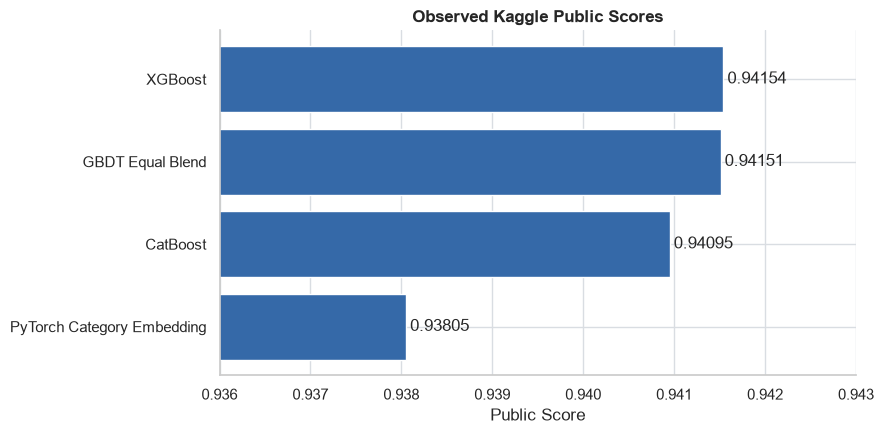

In [2]:
leaderboard_results = pd.DataFrame({
    "Submission": [
        "XGBoost",
        "GBDT Equal Blend",
        "CatBoost",
        "PyTorch Category Embedding",
    ],
    "Public_Score": [0.94154, 0.94151, 0.94095, 0.93805],
}).sort_values("Public_Score", ascending=False)

display(leaderboard_results)

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_data = leaderboard_results.sort_values("Public_Score")
bars = ax.barh(plot_data["Submission"], plot_data["Public_Score"], color=COLORS["blue"])
ax.set_xlim(0.936, 0.943)
ax.set(title="Observed Kaggle Public Scores", xlabel="Public Score", ylabel="")
ax.bar_label(bars, labels=[f"{value:.5f}" for value in plot_data["Public_Score"]], padding=3)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

XGBoost 与等权融合只相差 0.00003，但方向非常重要：CatBoost 和 PyTorch 分数更低，简单平均并没有带来净收益。因此后续候选只保留 XGBoost 主导的融合，而不再生成四模型等权版本。

### 2. Feature engineering ablation

In [3]:
feature_results = results[results["Experiment"].str.startswith("features_")][[
    "Experiment",
    "Tuning_ROC_AUC",
    "Holdout_ROC_AUC",
    "Holdout_Log_Loss",
    "Holdout_Average_Precision",
    "Best_Iteration",
    "Fit_Seconds",
]].copy()
feature_results["Feature_Set"] = feature_results["Experiment"].str.replace("features_", "", regex=False)
feature_results = feature_results.set_index("Feature_Set")
display(feature_results.drop(columns="Experiment").round(6))

feature_delta = (
    feature_results.loc["refined", "Holdout_ROC_AUC"]
    - feature_results.loc["legacy", "Holdout_ROC_AUC"]
)
print(f"Refined feature holdout ROC-AUC delta: {feature_delta:+.6f}")

,Tuning_ROC_AUC,Holdout_ROC_AUC,Holdout_Log_Loss,Holdout_Average_Precision,Best_Iteration,Fit_Seconds
Feature_Set,,,,,,
legacy,0.941590,0.941714,0.226564,0.757325,1396,39.364123
refined,0.941753,0.941855,0.226327,0.757754,1377,52.776966


Refined feature holdout ROC-AUC delta: +0.000141


新增特征包括补贴、家庭充电、环境关注度、收入和里程焦虑之间的定向交互，充电站平衡比例，非线性数值变换以及少量组合类别。提升在 tuning 与 holdout 上方向一致，因此比只在单一切分上涨更可信。

### 3. XGBoost parameter families

,Candidate,Tuning_ROC_AUC,Tuning_Log_Loss,Tuning_Average_Precision,Best_Iteration,Fit_Seconds
2,depth5_reference,0.941753,0.226657,0.756613,1377,58.427182
3,lossguide_31,0.941687,0.226779,0.756653,1516,66.579985
4,depth4_regularized,0.941675,0.226854,0.756649,1799,70.185981
5,depth6_regularized,0.941594,0.226919,0.755939,1150,52.843799


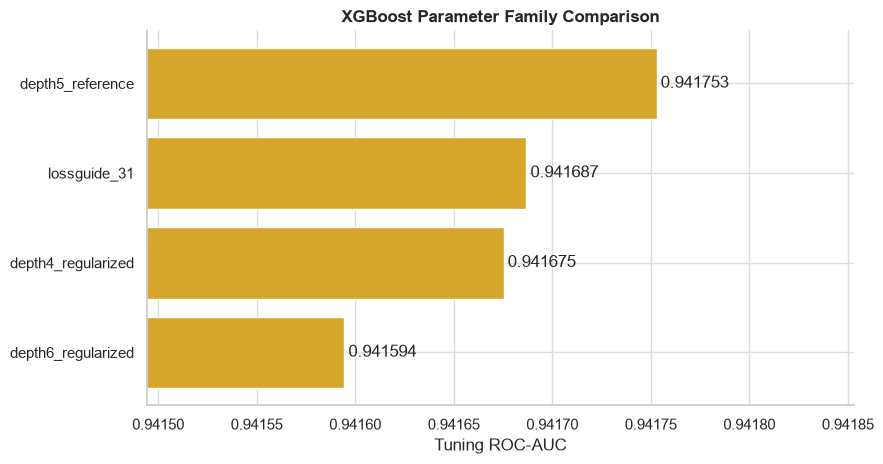

In [4]:
parameter_results = results[results["Experiment"].str.startswith("parameters_")][[
    "Candidate",
    "Tuning_ROC_AUC",
    "Tuning_Log_Loss",
    "Tuning_Average_Precision",
    "Best_Iteration",
    "Fit_Seconds",
]].sort_values("Tuning_ROC_AUC", ascending=False)
display(parameter_results.round(6))

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_data = parameter_results.sort_values("Tuning_ROC_AUC")
bars = ax.barh(plot_data["Candidate"], plot_data["Tuning_ROC_AUC"], color=COLORS["gold"])
ax.set_xlim(plot_data["Tuning_ROC_AUC"].min() - 0.0001, plot_data["Tuning_ROC_AUC"].max() + 0.0001)
ax.set(title="XGBoost Parameter Family Comparison", xlabel="Tuning ROC-AUC", ylabel="")
ax.bar_label(bars, labels=[f"{value:.6f}" for value in plot_data["Tuning_ROC_AUC"]], padding=3)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

浅树、深树强正则和 `lossguide` 都未超过 `depth5_reference`。差异虽小，但 tuning 排名清晰；继续扩大同类深度搜索的预期收益较低，后续更值得投入多折训练和低相关模型融合。

### 4. Original-data augmentation

,Original_Weight,Tuning_ROC_AUC,Holdout_ROC_AUC,Holdout_Log_Loss,Best_Iteration
6,0.0,0.941753,0.941855,0.226327,1377
8,1.0,0.934115,0.934545,0.350571,25
7,3.0,0.935673,0.935920,0.298345,56
9,5.0,0.933748,0.934178,0.302670,52


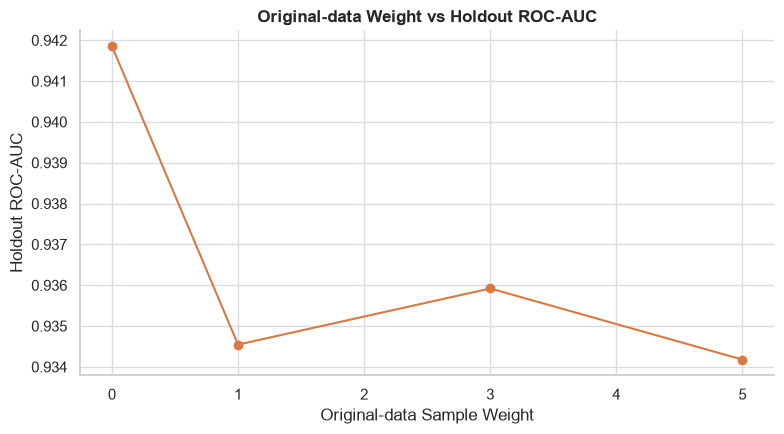

In [5]:
augmentation_results = results[results["Experiment"].str.startswith("original_weight_")][[
    "Original_Weight",
    "Tuning_ROC_AUC",
    "Holdout_ROC_AUC",
    "Holdout_Log_Loss",
    "Best_Iteration",
]].sort_values("Original_Weight")
display(augmentation_results.round(6))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    augmentation_results["Original_Weight"],
    augmentation_results["Holdout_ROC_AUC"],
    marker="o",
    color=COLORS["orange"],
)
ax.set(title="Original-data Weight vs Holdout ROC-AUC", xlabel="Original-data Sample Weight", ylabel="Holdout ROC-AUC")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

原始数据增强出现大幅、重复的性能下降，且最佳迭代轮数骤降，说明它改变了优化目标而不是提供同分布补充样本。该结果足以拒绝此方案；下载的原始数据只保留作审计证据，不进入最终训练。

### 5. New submission candidates

In [6]:
candidate_files = [
    "submission_xgboost_optimized_seed_ensemble.csv",
    "submission_optimized_xgb_blend_90_05_05.csv",
    "submission_optimized_xgb_blend_previous_75_25.csv",
    "submission_xgboost.csv",
    "submission_catboost.csv",
    "submission_lightgbm.csv",
]

prediction_columns = {}
submission_summary_rows = []
for filename in candidate_files:
    path = SUBMISSION_DIR / filename
    submission = pd.read_csv(path)
    prediction_columns[filename] = submission["Will_Buy_EV"]
    submission_summary_rows.append({
        "File": filename,
        "Rows": len(submission),
        "Mean": submission["Will_Buy_EV"].mean(),
        "Std": submission["Will_Buy_EV"].std(),
        "Min": submission["Will_Buy_EV"].min(),
        "Max": submission["Will_Buy_EV"].max(),
    })

submission_summary = pd.DataFrame(submission_summary_rows).set_index("File")
prediction_correlation = pd.DataFrame(prediction_columns).corr()
display(submission_summary.round(6))
display(prediction_correlation.round(6))

,Rows,Mean,Std,Min,Max
File,,,,,
submission_xgboost_optimized_seed_ensemble.csv,286571,0.174680,0.269664,0.000017,0.980578
submission_optimized_xgb_blend_90_05_05.csv,286571,0.174684,0.269523,0.000018,0.979954
submission_optimized_xgb_blend_previous_75_25.csv,286571,0.174685,0.269466,0.000017,0.978663
submission_xgboost.csv,286571,0.174698,0.269031,0.000013,0.972915
submission_catboost.csv,286571,0.174705,0.268242,0.000003,0.981286
submission_lightgbm.csv,286571,0.174722,0.269327,0.000035,0.979332


,submission_xgboost_optimized_seed_ensemble.csv,submission_optimized_xgb_blend_90_05_05.csv,submission_optimized_xgb_blend_previous_75_25.csv,submission_xgboost.csv,submission_catboost.csv,submission_lightgbm.csv
submission_xgboost_optimized_seed_ensemble.csv,1.000000,0.999984,0.999950,0.999202,0.997573,0.998130
submission_optimized_xgb_blend_90_05_05.csv,0.999984,1.000000,0.999967,0.999318,0.997900,0.998402
submission_optimized_xgb_blend_previous_75_25.csv,0.999950,0.999967,1.000000,0.999551,0.997926,0.998333
submission_xgboost.csv,0.999202,0.999318,0.999551,1.000000,0.998391,0.998346
submission_catboost.csv,0.997573,0.997900,0.997926,0.998391,1.000000,0.997736
submission_lightgbm.csv,0.998130,0.998402,0.998333,0.998346,0.997736,1.000000


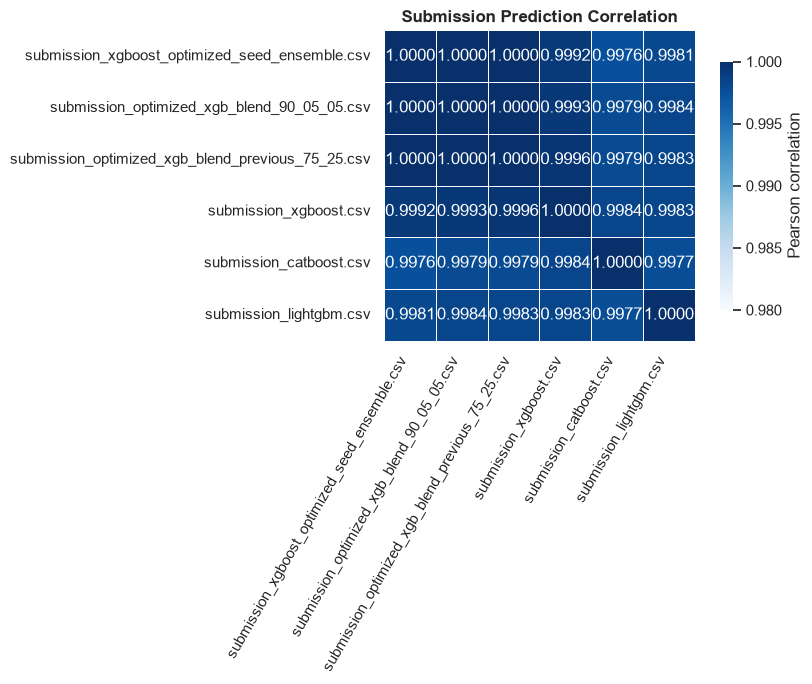

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    prediction_correlation,
    annot=True,
    fmt=".4f",
    cmap="Blues",
    vmin=0.98,
    vmax=1.0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation", "shrink": 0.8},
    ax=ax,
)
ax.set_title("Submission Prediction Correlation")
plt.xticks(rotation=60, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Takeaways

### 建议提交顺序

1. `submission_xgboost_optimized_seed_ensemble.csv`：最直接地体现全量训练、精细特征和三随机种子降方差。
2. `submission_optimized_xgb_blend_90_05_05.csv`：90% 优化 XGBoost，CatBoost 与 LightGBM 各 5%，用于测试少量跨模型多样性。
3. `submission_optimized_xgb_blend_previous_75_25.csv`：新旧 XGBoost 的保守混合，用于降低单一特征方案的风险。

不要一次提交三个种子单模；它们高度相关，提供的信息量低于上述三个结构不同的候选。等新公榜分数返回后，再决定下一轮是扩大多折种子集成，还是针对有效的融合方向细调权重。

### 可复现文件

- 训练与提交生成：`optimize_xgboost_leaderboard.py`
- 完整实验表：`artifacts/xgboost_optimization_results.csv`
- 最终选择元数据：`artifacts/xgboost_optimization_metadata.json`